In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
def plot_publications_by_year(df, year_col='Year', figsize=(8, 3), title='Distribution of Publications per Year'):
    """
    Plot the distribution of publications per year from a dataframe.
    """
    year_counts = df[year_col].value_counts().sort_index()
    plt.figure(figsize=figsize)
    plt.bar(year_counts.index, year_counts.values)
    plt.ylabel('Number of Publications')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [19]:
repo_names = ['acl', 'acm', 'arxiv', 'dblp', 'ieee', 'scopus', 'springer']
# Load and save to a dictionary of dataframes
dataframes = {repo: pd.read_pickle(f'../results/{repo}_results.pkl') for repo in repo_names}

In [20]:
for repo, df in dataframes.items():
    print(f'Engine: {repo.upper()}')
    display(df.head(1))

Engine: ACL


,ACL Key,URL,Publisher,Year,Title,Abstract,Venue,Authors,DOI,Journal
751,hong-etal-2025-ncl,https://aclanthology.org/2025.semeval-1.39/,Association for Computational Linguistics,2025,NCL-UoR at SemEval-2025 Task 3: Detecting Mult...,SemEval-2025 Task 3 (Mu-SHROOM) focuses on det...,Proceedings of the 19th International Workshop...,"Hong, Jiaying and Markchom, Thanet and Xu, J...",NaN,NaN


Engine: ACM


,Title,Authors,Year,Venue,Journal,Publisher,Abstract,DOI,URL
0,A Question Answering System for Aerospace Larg...,"Chen, Fei and Wen, Zhonghua and Liu, Bo",2025,Proceedings of the 2025 6th International Conf...,NaN,Association for Computing Machinery,"At present, the data in the aerospace science ...",10.1145/3756580.3756654,https://doi.org/10.1145/3756580.3756654


Engine: ARXIV


...

,Title,Authors,Year,Venue,Journal,Publisher,Abstract,DOI,URL
0,NaN,"Anthapu, Ravindranatha and Agarwal, Siddhant a...",2025,Building Neo4j-Powered Applications with LLMs:...,NaN,Packt Publishing,A comprehensive guide to building cutting-edge...,,https://ieeexplore.ieee.org/document/11099031


Engine: SCOPUS


,Title,Authors,DOI,Year,Abstract,Scopus ID,URL
0,KG-EGV: A Framework for Question Answering wit...,Hou K.,10.3390/electronics13234835,2024,None,SCOPUS_ID:85211914102,https://api.elsevier.com/content/abstract/scop...


Engine: SPRINGER


,Title,Authors,Year,Venue,DOI,URL,Type
0,Interactive and&#xa0;Provenance-Aware Search a...,Iordanis SapidisValantis ZervosMichalis Mounta...,2026,New Trends in Theory and Practice of Digital L...,10.1007/978-3-032-06136-2_24,https://link.springer.com/chapter/10.1007/978-...,Conference paper


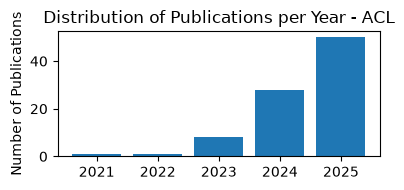

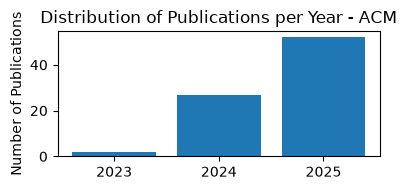

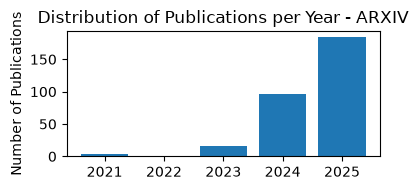

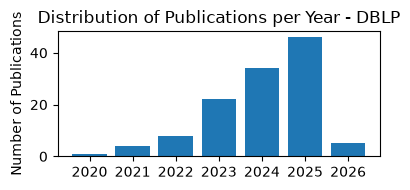

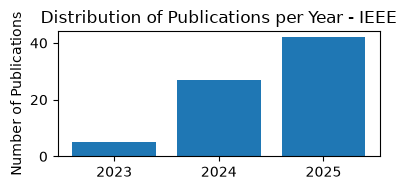

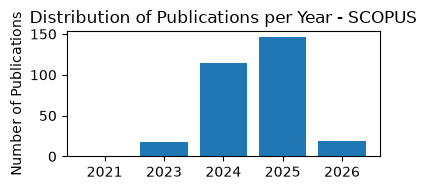

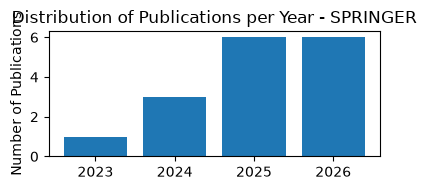

In [21]:
# Print distribution of publication years
for repo, df in dataframes.items():
    plot_publications_by_year(df, title=f'Distribution of Publications per Year - {repo.upper()}', figsize=(4, 2))

In [22]:
# Print number of publications per repository
for repo, df in dataframes.items():
    print(f'Number of publications in {repo.upper()}: {len(df)}')

Number of publications in ACL: 88
Number of publications in ACM: 81
Number of publications in ARXIV: 300
Number of publications in DBLP: 120
Number of publications in IEEE: 74
Number of publications in SCOPUS: 299
Number of publications in SPRINGER: 16


In [23]:
# Merge all dataframes for combined analysis
combined_df = pd.concat(dataframes.values(), ignore_index=True)
combined_df.head(2)

,ACL Key,URL,Publisher,Year,Title,Abstract,Venue,Authors,DOI,Journal,Type,DBLP Key,Scopus ID
0,hong-etal-2025-ncl,https://aclanthology.org/2025.semeval-1.39/,Association for Computational Linguistics,2025,NCL-UoR at SemEval-2025 Task 3: Detecting Mult...,SemEval-2025 Task 3 (Mu-SHROOM) focuses on det...,Proceedings of the 19th International Workshop...,"Hong, Jiaying and Markchom, Thanet and Xu, J...",NaN,NaN,NaN,NaN,NaN
1,creo-etal-2025-cogumelo,https://aclanthology.org/2025.semeval-1.281/,Association for Computational Linguistics,2025,COGUMELO at SemEval-2025 Task 3: A Synthetic A...,"In this paper, we propose an approach to detec...",Proceedings of the 19th International Workshop...,"Creo, Aldan and Cerezo - Costas, H{\'e}ctor ...",NaN,NaN,NaN,NaN,NaN


In [24]:
# Convert column Year to text
combined_df['Year'] = combined_df['Year'].astype(str)

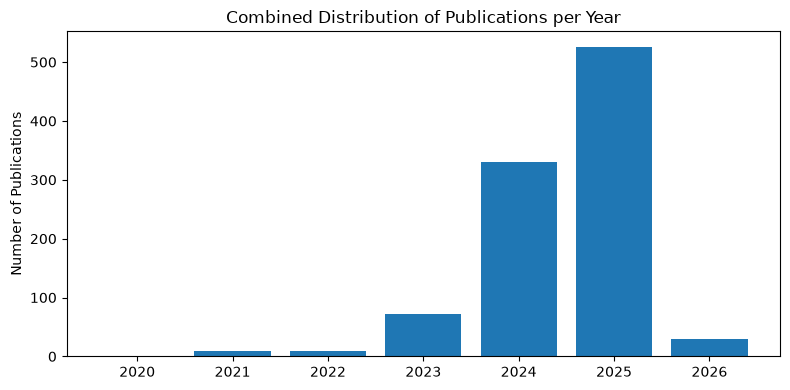

In [25]:
# Plot combined distribution of publication years
plot_publications_by_year(combined_df, title='Combined Distribution of Publications per Year', figsize=(8, 4))

In [26]:
# Print total number of publications
print(f'Total number of publications across all repositories: {len(combined_df)}')

# Print number of duplicates in column 'Title'
duplicates = combined_df['Title'].duplicated().sum()
print(f'Number of duplicate titles across all repositories: {duplicates}')

Total number of publications across all repositories: 978
Number of duplicate titles across all repositories: 200


In [27]:
combined_df.describe()

,ACL Key,URL,Publisher,Year,Title,Abstract,Venue,Authors,DOI,Journal,Type,DBLP Key,Scopus ID
count,88,897,167,978,977,535,357,960,551,22,136,120,299
unique,88,897,15,7,777,516,218,928,407,19,4,120,299
top,hong-etal-2025-ncl,https://aclanthology.org/2025.semeval-1.39/,Association for Computational Linguistics,2025,HyPA-RAG: A Hybrid Parameter Adaptive Retrieva...,Retrieval-augmented generation (RAG) has emerg...,EMNLP,Agrawal G.,10.1007/978-3-031-43458-7_34,IEEE Access,Conference and Workshop Papers,journals/tkde/YangCLDW24,SCOPUS_ID:85211914102
freq,1,1,82,526,4,2,19,3,4,3,91,1,1


In [28]:
# Export the combined dataframe to an Excel file
combined_df.to_excel('../files/combined_publications.xlsx', index=False)

In [29]:
combined_df.isna().sum()

ACL Key      890
URL           81
Publisher    811
Year           0
Title          1
Abstract     443
Venue        621
Authors       18
DOI          427
Journal      956
Type         842
DBLP Key     858
Scopus ID    679
dtype: int64

In [30]:
dataframes['acl'].head(2)

,ACL Key,URL,Publisher,Year,Title,Abstract,Venue,Authors,DOI,Journal
751,hong-etal-2025-ncl,https://aclanthology.org/2025.semeval-1.39/,Association for Computational Linguistics,2025,NCL-UoR at SemEval-2025 Task 3: Detecting Mult...,SemEval-2025 Task 3 (Mu-SHROOM) focuses on det...,Proceedings of the 19th International Workshop...,"Hong, Jiaying and Markchom, Thanet and Xu, J...",NaN,NaN
992,creo-etal-2025-cogumelo,https://aclanthology.org/2025.semeval-1.281/,Association for Computational Linguistics,2025,COGUMELO at SemEval-2025 Task 3: A Synthetic A...,"In this paper, we propose an approach to detec...",Proceedings of the 19th International Workshop...,"Creo, Aldan and Cerezo - Costas, H{\'e}ctor ...",NaN,NaN


In [31]:
# Read deduplicated dataframe from Excel file
deduplicated_df = pd.read_excel('../files/deduplicated_publications.xlsx')
deduplicated_df.head(2)

,Title,Authors,Year,Type,Publisher,Venue,Journal,DOI,DOI Link,URL
0,Decoding by Contrasting Knowledge: Enhancing L...,"Baolong Bi, Shenghua Liu, Lingrui Mei, Yiwei W...",2025,Conference and Workshop Papers,NaN,ACL,NaN,https://dblp.org/rec/conf/acl/BiLMWFJC25,NaN,NaN
1,Cracking Factual Knowledge: A Comprehensive An...,"Yuheng Chen, Pengfei Cao, Yubo Chen 0001, Yini...",2025,Conference and Workshop Papers,NaN,ACL,NaN,https://dblp.org/rec/conf/acl/ChenC0WL0025,NaN,NaN


In [32]:
# Drop DOI, DOI Link, URL, Authors, Publisher columns from the deduplicated dataframe
columns_to_drop = ['DOI', 'DOI Link', 'URL', 'Authors', 'Publisher']
deduplicated_df = deduplicated_df.drop(columns=columns_to_drop)
deduplicated_df.head(2)

,Title,Year,Type,Venue,Journal
0,Decoding by Contrasting Knowledge: Enhancing L...,2025,Conference and Workshop Papers,ACL,NaN
1,Cracking Factual Knowledge: A Comprehensive An...,2025,Conference and Workshop Papers,ACL,NaN


In [33]:
deduplicated_df.isna().sum()

Title        0
Year         0
Type       367
Venue      145
Journal    463
dtype: int64

In [34]:
# Convert column Year to text
deduplicated_df['Year'] = deduplicated_df['Year'].astype(str)

# Merge 2026 entries to 2025 as they are early access publications
deduplicated_df['Year'] = deduplicated_df['Year'].replace('2026', '2025')

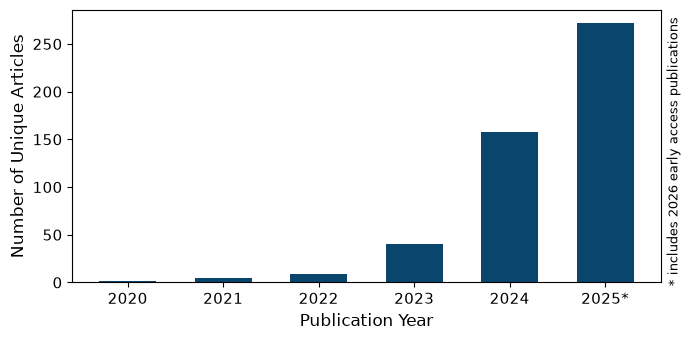

In [35]:
# Merge 2026 entries to 2025 as they are early access publications
deduplicated_df['Year'] = deduplicated_df['Year'].replace('2026', '2025')

# Plot again, changing the label of 2025 to 2025* and add a note about early access publications
deduplicated_df['Year'] = deduplicated_df['Year'].replace('2025', '2025*')

year_counts = deduplicated_df['Year'].value_counts().sort_index()
plt.figure(figsize=(7, 3.5))
plt.bar(year_counts.index, year_counts.values, width=0.6, color='#0a456e')
plt.ylabel('Number of Unique Articles', fontsize=12)
plt.xlabel('Publication Year', fontsize=12)
# Change ticks size
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
# Add vertical side note
plt.text(
    1.01, 0.48, '* includes 2026 early access publications',
    rotation=90,
    transform=plt.gca().transAxes,
    va='center',
    ha='left',
    fontsize=9
)
plt.tight_layout()
plt.savefig('../files/imgs/publications_per_year.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [36]:
organizations = [
    "Microsoft",
    "Microsoft", "Google", "Meta", "OpenAI",
    "Stanford", "Meta", "OpenAI", "Alibaba", "Meta",
    "Meta", "Stability AI", "Mistral AI", "Alibaba",
    "Sapienza", "Ministral AI",
    "Meta",
    "BigScience",
    "OpenAI", "Meta",
    "Meta", "Alibaba",
    "OpenAI",
    "OpenAI", "LMSYS Org",
    "Meta",
    "Meta", "OpenAI", "BigScience", "Stanford", "LMSYS Org", "EleutherAI",
    "OpenAI",
    "OpenAI", "EleutherAI", "LMSYS Org",
    "OpenAI", "Other",
    "Meta",
    "Mistral",
    "Meta", "OpenAI",
    "OpenAI", "LMSYS Org",
    "Meta", "Microsoft", "Alibaba",
    "OpenAI",
    "Meta", "HuggingFace",
    "Google", "BigScience", "Meta", "OpenAI",
    "Meta", "Google"
]

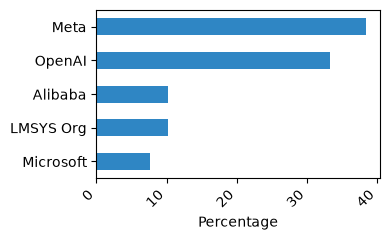

In [37]:
# Bar chart for organizations
org_counts = pd.Series(organizations).value_counts()
# Keep top 5 organizations
org_counts = org_counts.nlargest(5)
# Invert the order of the organizations for better visualization
org_counts = org_counts[::-1]

# Normalize the counts to percentages
org_counts = (org_counts / org_counts.sum()) * 100

plt.figure(figsize=(4, 2.5))
org_counts.plot(kind='barh', color="#2F86C4")
plt.xlabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../files/imgs/organizations_distribution.pdf', format='pdf')

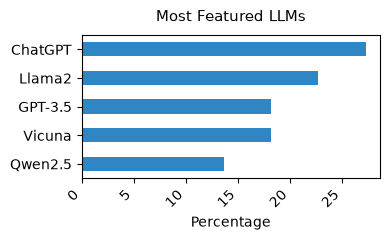

In [38]:
models = [ "Phi-4", "GODEL", "T5", "RoBERTa Enc-Dec", "ChatGPT", "Alpaca", "Llama2-Chat", "ChatGPT", "Qwen2.5", "Llama3.1", "Llama3.1", "Stable-LM-Alpha", "Mistral", "Qwen2.5", "QwQ", "Minerva", "Mistral", "Llama", "Bloom", "GPT-3.5", "Llama3",
          "Llama2", "Qwen2", "MedLLama", "GPT-3.5", "ChatGPT", "GPT-3.5", "Vicuna", "Llama2", "FLAN-T5", "FLAN-UL2", "Llama", "Vicuna", "Alpaca", "T0pp", "OPT", "Bloom", "FLAN-T5", "ChatGPT", "GPT-Neo", "GPT-J", "GPT2", "GPT-4", "GPT2", "GPT-3.5",
          "GPT-4", "Vicuna", "GPT-J", "GPT2-KG", "GPT2-KE", "DialGPT", "BART", "LLaVA-v1.6-Mistral", "Llama2", "ChatGPT", "GPT-4", "GPT-3", "Vicuna", "Llama3.3", "Phi-4", "Qwen2.5", "ChatGPT", "GPT-4o-mini", "Llama2", "Zephyr", "T5", "T0", "OPT", "GPT-3", "Llama2", "Gemma" ]

# Bar chart for models
model_counts = pd.Series(models).value_counts()
# Keep top 5 models
model_counts = model_counts.nlargest(5)
# Invert the order of the models for better visualization
model_counts = model_counts[::-1]

# Normalize the counts to percentages
model_counts = (model_counts / model_counts.sum()) * 100

plt.figure(figsize=(4, 2.5))
model_counts.plot(kind='barh', color="#2F86C4")
plt.xlabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.title('Most Featured LLMs', pad=10, fontsize=10.5)
plt.tight_layout()
plt.savefig('../files/imgs/models_distribution.pdf', format='pdf')

In [39]:
model_sizes = [
    14,
    0.22, 0.22, 0.125, 175, 7, 7, 175, 7, 70,
    8, 7, 7, 7, 32,
    0.35, 1, 3, 4, 7, 13, 0.56,
    175, 8, 70, 7, 7, 7, 175,
    175, 175, 13, 7, 3, 11, 19,
    7, 13, 7, 13, 11, 1.3, 2.7, 6.7, 13, 1.1, 1.7, 3, 7, 1.3, 1.5, 2.7, 6, 3, 11, 175, 175,
    1.5, 175, 175, 13, 6, 1.5, 0.124, 0.14, 7,
    13, 175, 175, 33, 175, 70, 14, 72, 7,
    175, 175, 13, 7, 7,
    0.8, 2, 11, 3, 11, 2.7, 6.7, 6.7, 175, 7, 13, 2
]

In [40]:
# Cluster models by size into small (<1B), medium (1B-10B), large (10B-100B), and very-large (>100B)
model_size_categories = []
for size in model_sizes:
    if size < 1:
        model_size_categories.append('<1B')
    elif 1 <= size < 10:
        model_size_categories.append('1B-10B')
    elif 10 <= size < 100:
        model_size_categories.append('10B-100B')
    else:
        model_size_categories.append('>100B')

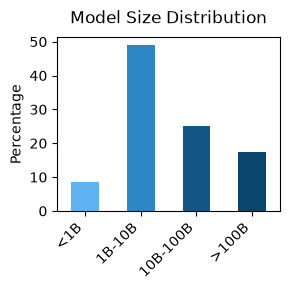

In [41]:
# Bar plot for model size categories
size_counts = pd.Series(model_size_categories).value_counts()
# Order by category size
size_counts = size_counts.reindex(['<1B', '1B-10B', '10B-100B', '>100B'])

# Normalize the counts to percentages
size_counts = (size_counts / size_counts.sum()) * 100

plt.figure(figsize=(3, 3))
size_counts.plot(kind='bar', color=["#5fb3f0", "#2F86C4", "#125686", "#0a456e"])
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.title('Model Size Distribution', pad=10, fontsize=12.5)
plt.tight_layout()
plt.savefig('../files/imgs/model_size_distribution.pdf', format='pdf')

In [42]:
areas = [
    "Information Systems", "Semantic Web", "ML", "NLP", "DB", "Expert Systems",
    "NLP", "AI", "AI", "ML", "Semantic Web", "NLP", "Expert Systems", "NLP",
    "AI", "NLP", "AI", "Information Systems", "NLP", "NLP", "NLP", "AI", "AI",
    "NLP", "Semantic Web", "AI", "NLP", "NLP", "NLP", "ML",
    "NLP", "ML", "NLP", "AI", "NLP", "IR", "NLP", "NLP"
]

publishers = [
    "Springer", "Springer", "IEEE", "ACL", "Springer", "Elsevier",
    "ACL", "AAAI", "CEUR", "PMLR", "Springer", "ACL", "Elsevier", "ACL",
    "AAAI", "ACL", "AAAI", "AIS", "ACL", "ACL", "ACL", "OpenReview", "PMLR",
    "ACL", "Springer", "OpenReview", "ACL", "ACL", "ACL", "OpenReview",
    "ACL", "OpenReview", "ACL", "Elsevier", "ACL", "ACM", "ACL", "ACL"
]

venue_types = [
    "Conference", "Conference", "Conference", "Conference", "Conference", "Journal",
    "Workshop", "Workshop", "Workshop", "Conference", "Conference", "Conference",
    "Journal", "Conference", "Conference", "Conference", "Conference", "Conference",
    "Conference", "Conference", "Conference", "Conference", "Conference",
    "Conference", "Conference", "Conference", "Conference", "Conference",
    "Workshop", "Conference",
    "Conference", "Conference", "Conference", "Journal", "Conference",
    "Conference", "Conference", "Conference"
]

venues = [
    "MCO", "KGSWC", "ICMLA", "EMNLP", "DEXA", "ESWA", "TrustNLP", "AAAI-SS",
    "KiL", "NeSy", "ESWC", "EMNLP", "ESWA", "ACL", "AAAI", "ACL", "AAAI",
    "ICIS", "EMNLP", "EMNLP", "ACL", "NeurIPS", "CPAL", "EMNLP", "ISWC",
    "ICML", "NAACL", "ACL", "NLRSE", "ICLR",
    "COLING", "ICLR", "EMNLP", "KBS", "ACL", "SIGIR", "EMNLP", "EMNLP"
]

In [43]:
# For areas, publishers, venue_types we can create pie charts to visualize the distribution of publications across these categories.
areas_counts = pd.Series(areas).value_counts()
publishers_counts = pd.Series(publishers).value_counts()
# Add Others for publishers with less than 5% of the total publications
publishers_counts = publishers_counts[publishers_counts > len(publishers) * 0.05]
publishers_counts['Others'] = len(publishers) - publishers_counts.sum()
venues_counts = pd.Series(venues).value_counts()
venue_types_counts = pd.Series(venue_types).value_counts()

In [44]:
colors = [
    "#618CBA",  # blue
    "#F28E2B",  # orange
    "#E15759",  # red
    "#76B7B2",  # teal
    "#59A14F",  # green
    "#EDC948",  # yellow
    "#B07AA1",  # purple
    "#FF9DA7",  # pink
    "#9C755F",  # brown
    "#BAB0AC",  # gray
]

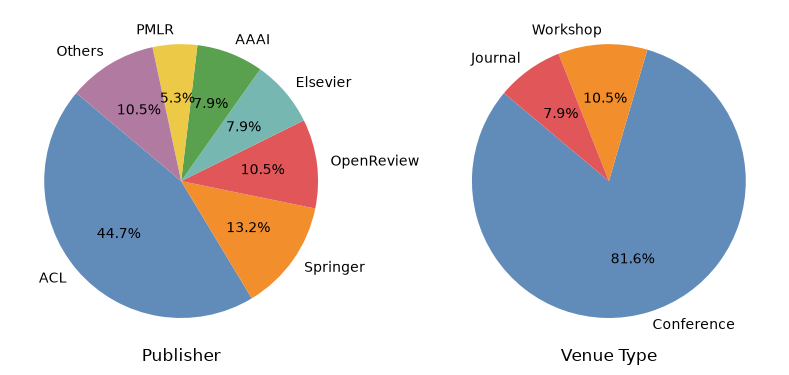

In [45]:
# Create a single plot area with the three pie charts for areas, publishers, and venue_types (no title for the figure, but each pie chart should have a title)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.pie(publishers_counts, labels=publishers_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Publisher', y=-0.05)
plt.subplot(1, 2, 2)
plt.pie(venue_types_counts, labels=venue_types_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Venue Type', y=-0.05)
plt.tight_layout()
plt.savefig('../files/imgs/publication_categories.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [46]:
venue_types = [
    "Conference","Conference","Conference","Conference","Conference","Journal","Workshop","Workshop","Workshop","Conference",
    "Conference","Conference","Journal","Conference","Conference","Conference","Conference","Conference","Conference","Conference",
    "Conference","Conference","Conference","Conference","Conference","Conference","Conference","Conference","Workshop","Conference",
    "Conference","Conference","Conference","Journal","Conference","Conference","Conference","Conference"
]

years = [
    "2025","2024","2023","2025","2025","2025","2024","2024","2024","2025",
    "2023","2024","2025","2024","2024","2024","2024","2024","2023","2021",
    "2023","2024","2025","2023","2025","2025","2022","2024","2023","2025",
    "2025","2025","2025","2025","2025","2025","2023","2024"
]

venue_df = pd.DataFrame({"Venue Type": venue_types, "Year": years}).apply(lambda col: col.astype(str).str.strip())
venue_df.head(2)

,Venue Type,Year
0,Conference,2025
1,Conference,2024


In [47]:
# Count number of Journal, Conference, and Workshop publications per year
venue_year_counts = venue_df.groupby(['Year', 'Venue Type']).size().unstack(fill_value=0)
stacked_venue_df = venue_year_counts.reindex(columns=['Journal', 'Conference', 'Workshop'], fill_value=0)
stacked_venue_df.index = stacked_venue_df.index.astype(int)
stacked_venue_df = stacked_venue_df.sort_index()
stacked_venue_df.head(2)

Venue Type,Journal,Conference,Workshop
Year,,,
2021,0,1,0
2022,0,1,0


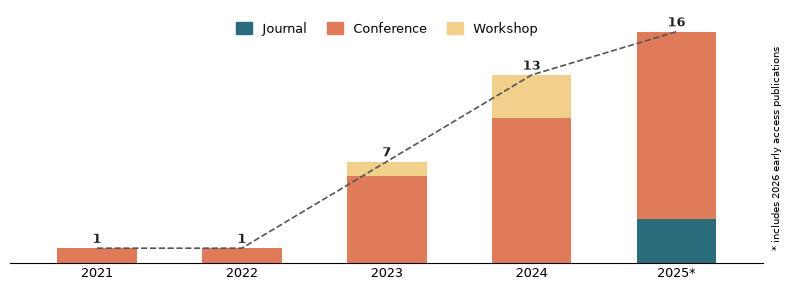

In [48]:
import matplotlib.patches as mpatches

colors = {
    'Journal':    '#2a6b7c',   # deep teal
    'Conference': '#e07b5a',   # soft coral
    'Workshop':   '#f0d08a',   # warm sand
}

categories = list(colors.keys())

fig, ax = plt.subplots(figsize=(8, 3))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

years = stacked_venue_df.index.tolist()
x = np.arange(len(years))
bar_width = 0.55

# Stacked bars
bottoms = np.zeros(len(years))
for category in categories:
    values = stacked_venue_df[category].values
    ax.bar(x, values, bottom=bottoms, width=bar_width,
           color=colors[category], label=category, zorder=2)
    bottoms += values

# Dashed trend line
totals = stacked_venue_df.sum(axis=1).values
ax.plot(x, totals, linestyle='--', color='#555555', linewidth=1.2, zorder=3)

# Annotate totals above bars
for i, total in enumerate(totals):
    ax.text(i, total + 0.15, str(int(total)),
            ha='center', va='bottom', fontsize=9.5,
            fontweight='bold', color='#222222')
    


# Axes formatting
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years], fontsize=9)
ax.set_xlim(-0.6, len(years) - 0.4)
ax.set_ylim(0, totals.max() + 1.5)
ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='x', length=0)

# Legend — centered above chart, 3 columns
handles = [mpatches.Patch(color=colors[c], label=c) for c in categories]
ax.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1),
    ncol=3,
    frameon=False,
    fontsize=9.5,
    handlelength=1.2,
    handleheight=1.0,
    columnspacing=1.5,
)

# Change xlabels to have 2025* instead of 2025
ax.set_xticklabels([str(y).replace('2025', '2025*') for y in years], fontsize=9)

# Add vertical side note
ax.text(
    1.01, 0.45, '* includes 2026 early access publications',
    rotation=90,
    transform=plt.gca().transAxes,
    va='center',
    ha='left',
    fontsize=7
)

plt.tight_layout()
plt.savefig('../files/imgs/publication_chart.pdf', bbox_inches='tight', format='pdf')
plt.show()